# TinyChirp CNN build pipeline\n
\n
Trains one CNN on log-mel spectrograms, exports an int8 TFLite model, and writes a Rust audio sample file.

In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
from typing import TYPE_CHECKING
from utils import (
    TARGET_FRAMES_MEL,
    TARGET_AUDIO_LEN_MEL,
    DATASET_ROOT,
    get_paths,
    configure_tf_runtime,
    set_global_seed,
)

if TYPE_CHECKING:
    import keras
else:
    from tensorflow import keras

configure_tf_runtime()
set_global_seed()

paths = get_paths("cnn_mel_tf")
OUT_TFLITE = paths.out_tflite
OUT_AUDIO_RS = paths.out_audio_rs
BATCH_SIZE = 32

print("Dataset root:", DATASET_ROOT)
print("Model output:", OUT_TFLITE)



Dataset root: /home/nathan/Documents/tiny-chirp-microflow/dataset
Model output: /home/nathan/Documents/tiny-chirp-microflow/models/cnn_mel_tf.tflite


In [8]:
from utils import (
    make_mel_datasets,
    NUM_MEL_BINS_MEL,
)

train_ds, val_ds, test_ds, label_names = make_mel_datasets(
    num_mel_bins=NUM_MEL_BINS_MEL,
    target_frames=TARGET_FRAMES_MEL,
)
num_labels = len(label_names)
print("Classes:", label_names)



Found 11292 files belonging to 2 classes.
Found 1380 files belonging to 2 classes.
Found 1393 files belonging to 2 classes.
Classes: ['non_target' 'target']


In [9]:
from utils import NUM_MEL_BINS_MEL, TARGET_FRAMES_MEL, init_wandb, get_callbacks, finish_wandb

CONV_FILTER_SIZE = 3
N_CHANNELS = 4

TARGET_FRAMES = TARGET_FRAMES_MEL
NUM_MEL_BINS = NUM_MEL_BINS_MEL

end_of_conv1_s1 = (TARGET_FRAMES - CONV_FILTER_SIZE + 1) // 2
end_of_conv2_s1 = (end_of_conv1_s1 - CONV_FILTER_SIZE + 1) // 2
end_of_conv1_s2 = (NUM_MEL_BINS - CONV_FILTER_SIZE + 1) // 2
end_of_conv2_s2 = (end_of_conv1_s2 - CONV_FILTER_SIZE + 1) // 2

model = keras.Sequential([
    keras.layers.Input(shape=(TARGET_FRAMES, NUM_MEL_BINS, 1)),
    keras.layers.Conv2D(N_CHANNELS, (CONV_FILTER_SIZE, CONV_FILTER_SIZE), activation="relu"),
    keras.layers.AveragePooling2D((2, 2)),
    keras.layers.Conv2D(N_CHANNELS, (CONV_FILTER_SIZE, CONV_FILTER_SIZE), activation="relu"),
    keras.layers.AveragePooling2D((2, 2)),
    keras.layers.Reshape((end_of_conv2_s2 * end_of_conv2_s1 * N_CHANNELS,)),
    keras.layers.Dense(8, activation="relu"),
    keras.layers.Dense(num_labels),
])
model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)



init_wandb("cnn_mel", config={
    "conv_filter_size": CONV_FILTER_SIZE,
    "n_channels": N_CHANNELS,
})

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=get_callbacks(10,5,BATCH_SIZE)
)
finish_wandb()

Epoch 1/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.9170 - loss: 0.2155 - val_accuracy: 0.9696 - val_loss: 0.0989
Epoch 2/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.9652 - loss: 0.0948 - val_accuracy: 0.9775 - val_loss: 0.0806
Epoch 3/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - accuracy: 0.9730 - loss: 0.0736 - val_accuracy: 0.9768 - val_loss: 0.0752
Epoch 4/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.9840 - loss: 0.0483 - val_accuracy: 0.9841 - val_loss: 0.0567
Epoch 5/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.9870 - loss: 0.0363 - val_accuracy: 0.9855 - val_loss: 0.0604
Epoch 6/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.9880 - loss: 0.0351 - val_accuracy: 0.9833 - val_loss: 0.0615
Epoch 7/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.9916 - loss: 0.0232 - val_accuracy: 0.9891 - val_loss: 0.0446
Epoch 8/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.9951 - loss: 0

batch/accuracy,▁▂▃▄▄▆▆▇▇▇▇▇▇▇▇▇▇███████████████████████
batch/batch_step,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇█████
batch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/loss,█▇▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,▁▅▆▇▇▇▇██████████
epoch/epoch,▁▁▂▂▃▃▄▄▅▅▅▆▆▇▇██
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▃▃▆▆▅▇▆▆▆█████▆█
epoch/val_loss,█▆▅▃▃▃▁▂▂█▃▄▂▄▄▅▄
+6,...


In [10]:
from utils import (
    build_representative_batches,
    export_keras_model_to_int8_tflite,
)

val_specs = build_representative_batches(test_ds, take=100)

try:
    export_keras_model_to_int8_tflite(model, val_specs, OUT_TFLITE)
    print(f"Success! Wrote {OUT_TFLITE}")
except Exception as e:
    print(f"Conversion failed: {e}")

INFO:tensorflow:Assets written to: temp_saved_model/assets


2026-04-16 16:37:54.396350: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
INFO:tensorflow:Assets written to: temp_saved_model/assets


Saved artifact at 'temp_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 184, 80, 1), dtype=tf.float32, name='keras_tensor_8')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  139951768458464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139951768457584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139951768458112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139951768456000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139951768457408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139951768463744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139951768455648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139951768463568: TensorSpec(shape=(), dtype=tf.resource, name=None)
Success! Wrote /home/nathan/Documents/tiny-chirp-microflow/models/cnn_mel_tf.tflite


W0000 00:00:1776350274.633503   25083 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1776350274.633594   25083 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-04-16 16:37:54.635974: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: temp_saved_model
2026-04-16 16:37:54.636406: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-16 16:37:54.636415: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: temp_saved_model
2026-04-16 16:37:54.641483: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2026-04-16 16:37:54.642093: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-04-16 16:37:54.663831: I tensorflow/cc/saved_model/loader.cc:218] Running initialization op on SavedModel bundle at path: temp_saved_model
2026-04-16 16:37:54.669923: I tensorflow/cc/saved_model/loader.cc

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
2026-04-16 16:38:15.220386: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-16 16:38:17.666450: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


=== Binary classifier metrics : TEST SET===
Threshold: 0.1987  (best F2 threshold)
Accuracy : 0.9734
Precision: 0.9305
Recall   : 0.9934
F2 score : 0.9802
=== Binary classifier metrics : TRAIN SET===
AUC      : 0.9999


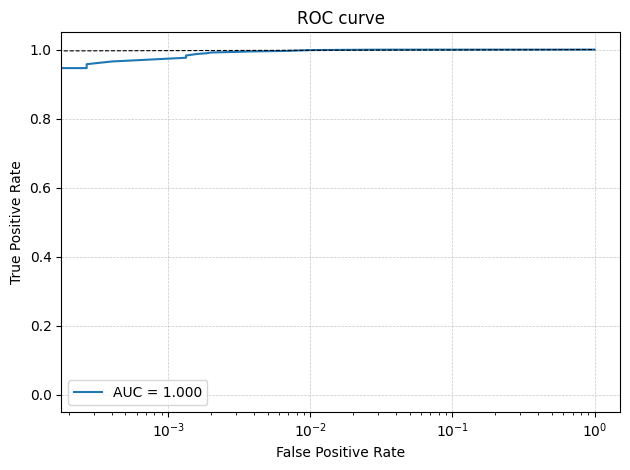

Avg inference: 1.181 ms


In [11]:
from utils import evaluate_tflite_model

train_m, test_m, avg_ms = evaluate_tflite_model(OUT_TFLITE, "cnn_mel_tf", train_ds, test_ds)
print(f"Avg inference: {avg_ms:.3f} ms")